# MWE: the optional NUFFT backend

An `Image` computes its visibilities exactly by default, as a sum over pixels done with two matrix products (the DFT). For large images observed at many irregularly placed uv points, as in long-baseline interferometry with VLTI or CHARA or with sparse masks on the LBT, that sum becomes expensive. `Image(..., backend="nufft")` then uses a non-uniform FFT from the optional `jax-finufft` package (`pip install 'drpangloss[nufft]'`), which is approximate to a requested relative tolerance of 1e-7 in float64 and 1e-5 in float32.

This notebook measures how accurate the NUFFT is against the exact DFT, where its errors matter, and when it is faster. You should come away knowing when to switch backends. For gridded data such as AMI, see the uv-lattice MWE instead.

In [1]:
import sys
import time
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
from tqdm.auto import tqdm

from drpangloss._geometry import image_visibilities
from drpangloss.models import Image, PointSource, System
from drpangloss.scenes import gaussian_blob, ring

npix, scale = 128, 0.25  # a 32 mas field, CHARA-like resolution
truth = 0.8 * ring(
    npix, scale, 6.0, 0.8, inc_deg=40.0, pa_deg=60.0, asymmetry=0.4
) + 0.2 * gaussian_blob(npix, scale, 0.6, dra=-4.0, ddec=3.0)
truth = truth / truth.sum()
rng = onp.random.default_rng(0)
fmax = 330.0 / 1.6e-6  # baselines up to 330 m at 1.6 µm, as at CHARA
uu, vv = rng.uniform(-fmax, fmax, (2, 20_000))
print(f"{npix}² image with {scale} mas pixels, {uu.size} irregular uv points")

128² image with 0.25 mas pixels, 20000 irregular uv points


## Accuracy against the exact transform

FINUFFT's tolerance is relative to the whole output vector, so single visibilities can be a little worse. For a unit-sum image the zero-baseline visibility is one, and the tests require every point to be within 3 × eps of the DFT. The histograms show the actual errors in each precision: all well inside that bound.

W0930 22:18:25.257170 9827313 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


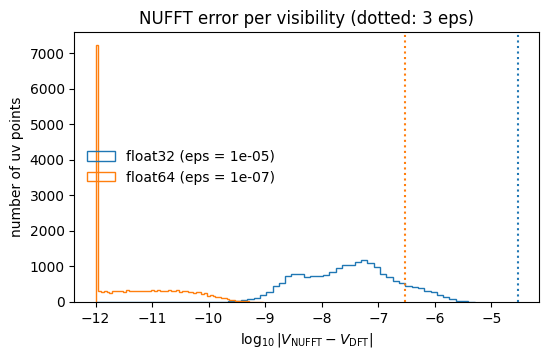

In [2]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for x64, eps in [(False, 1e-5), (True, 1e-7)]:
    with jax.enable_x64(x64):
        image = jnp.asarray(truth, dtype=float)
        error = jnp.abs(
            image_visibilities(image, uu, vv, scale, "nufft")
            - image_visibilities(image, uu, vv, scale)
        )
        label = f"{'float64' if x64 else 'float32'} (eps = {eps:.0e})"
        ax.hist(
            onp.log10(onp.maximum(onp.asarray(error), 1e-12)),
            bins=60,
            histtype="step",
            label=label,
        )
        ax.axvline(
            onp.log10(3 * eps), color=ax.patches[-1].get_edgecolor(), ls=":"
        )
ax.set(
    xlabel=r"$\log_{10} |V_{\rm NUFFT} - V_{\rm DFT}|$",
    ylabel="number of uv points",
    title="NUFFT error per visibility (dotted: 3 eps)",
)
ax.legend(frameon=False)
plt.show()

## Where the error matters: phases of faint visibilities

An absolute error δV turns into a phase error of about δV/|V|, so faint visibilities, near the nulls of a resolved source, carry the largest phase errors (below |V| ~ 1e-3 no instrument measures a phase anyway). In float32 the phase errors are about 1e-5 rad for bright visibilities and 1e-4 rad near |V| ~ 1e-3. That is fine for long-baseline closure phases (errors of 0.2–1°), but not for the ~2e-5 rad closure phases needed for high-contrast AMI. There, use the exact DFT or MFT.

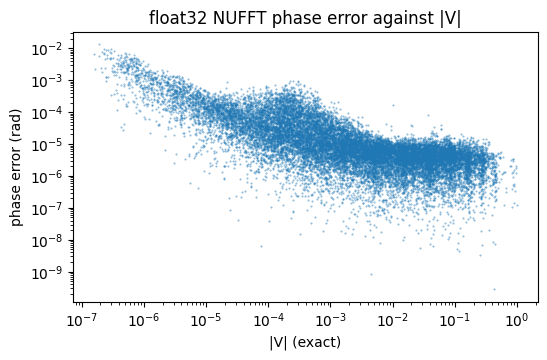

In [3]:
image = jnp.asarray(truth)
dft = image_visibilities(image, uu, vv, scale)
nufft = image_visibilities(image, uu, vv, scale, "nufft")
phase_error = jnp.abs(jnp.angle(nufft / dft))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.loglog(jnp.abs(dft), phase_error, ".", ms=1, alpha=0.5)
ax.set(
    xlabel="|V| (exact)",
    ylabel="phase error (rad)",
    title="float32 NUFFT phase error against |V|",
)
plt.show()

## When it is faster

The DFT's cost grows as (number of points) × npix², and the NUFFT's roughly as npix² log npix plus the number of points. This cell times a jitted value-and-gradient of Σ|V|² for both, at a fixed 128² image, over a range of dataset sizes. On a laptop CPU the DFT wins below about a thousand points, and the NUFFT wins by more than an order of magnitude at 10⁵.

dft:   0%|          | 0/6 [00:00<?, ?it/s]

nufft:   0%|          | 0/6 [00:00<?, ?it/s]

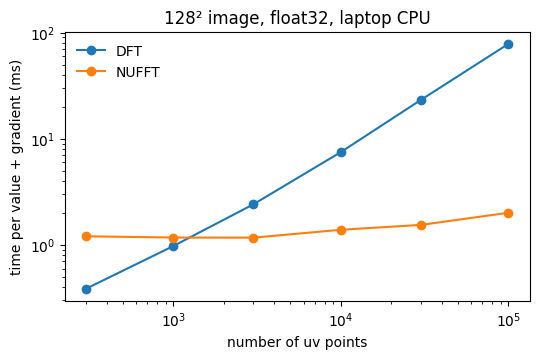

In [4]:
def timed(backend, n):
    loss = jax.jit(
        jax.value_and_grad(
            lambda img: jnp.sum(
                jnp.abs(
                    image_visibilities(img, uu[:n], vv[:n], scale, backend)
                )
                ** 2
            )
        )
    )
    jax.block_until_ready(loss(image))
    start = time.perf_counter()
    for _ in range(5):
        jax.block_until_ready(loss(image))
    return (time.perf_counter() - start) / 5 * 1e3


uu, vv = rng.uniform(-fmax, fmax, (2, 100_000))
sizes = [300, 1_000, 3_000, 10_000, 30_000, 100_000]
times = {
    b: [timed(b, n) for n in tqdm(sizes, desc=b)] for b in ("dft", "nufft")
}
fig, ax = plt.subplots(figsize=(6, 3.5))
for backend, ms in times.items():
    ax.loglog(sizes, ms, "-o", label=backend.upper())
ax.set(
    xlabel="number of uv points",
    ylabel="time per value + gradient (ms)",
    title=f"{npix}² image, float32, laptop CPU",
)
ax.legend(frameon=False)
plt.show()

## Switching backends in a model

The backend is one argument of `Image`, so the same scene can be evaluated either way. Inside a `System` with an analytic star, the two backends agree to within the float32 NUFFT tolerance.

In [5]:
def scene(backend):
    envelope = Image.from_brightness(truth, scale, flux=0.5, backend=backend)
    return System(star=PointSource(), env=envelope)


u, v = uu[:500] * 1.6e-6, vv[:500] * 1.6e-6  # baselines in metres at 1.6 µm
difference = jnp.abs(
    scene("nufft").model(u, v, 1.6e-6) - scene("dft").model(u, v, 1.6e-6)
).max()
print(f"largest difference between the backends: {difference:.1e}")

largest difference between the backends: 8.9e-07


## Summary

The NUFFT backend is a drop-in, approximate alternative to the exact DFT, with errors per visibility of order 1e-6 in float32 and 1e-8 in float64 for unit-sum images. It pays off for large images and large, irregular datasets such as long-baseline interferometry, where it is 10–100× faster. Keep the DFT (or, for gridded AMI data, the MFT) for small datasets and whenever float32 phases must be accurate to better than about 1e-4 rad. On an A100 GPU the picture changes: jax-finufft re-plans on every call, costing about 7 ms, so there the DFT is faster except for the very largest problems (512² images with 10⁵ points); see the GPU benchmark in `design/image_reconstruction.md`.